<a href="https://colab.research.google.com/github/Droc-sid/Droc-sid/blob/Notebooks/ADVANCED_DATA_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

JOMO KENYATTA UNIVERSITY
OF AGRICULTURE & TECHNOLOGY

CAT 3 - APRIL 2026
SEMESTER II, YEAR IV
BSC. DATA SCIENCE & ANALYTICS

SDS 2410 : ADVANCED DATA ANALYTICS USING SPREADSHEETS

MIKE MASYUKI SAMMY
SCT213-C002-0025/2022

In [ ]:
!pip install scipy matplotlib pandas numpy seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
#  QUESTION ONE
## Forecasting, Simulation, and Decision Analytics Dataset

In [ ]:
# Q1 DATA — Build the Dataset
q1_data = {
    'Month':       ['M1','M2','M3','M4','M5','M6','M7'],
    'Sales':       [100, 120, 140, 160, 180, 170, 190],
    'Marketing':   [ 20,  25,  30,  35,  40,  38,  42],
    'RiskIndex':   [0.30, 0.40, 0.50, 0.60, 0.70, 0.65, 0.75],
    'Demand':      [110, 130, 150, 170, 190, 185, 200],
    'PriceIndex':  [1.05, 1.10, 1.15, 1.20, 1.25, 1.22, 1.30],
    'Seasonality': ['Low','Medium','Medium','High','High','High','Peak']
}
q1 = pd.DataFrame(q1_data)
print('QUESTION ONE — Dataset')
print('=' * 70)
print(q1.to_string(index=False))

QUESTION ONE — Dataset
Month  Sales  Marketing  RiskIndex  Demand  PriceIndex Seasonality
   M1    100         20       0.30     110        1.05         Low
   M2    120         25       0.40     130        1.10      Medium
   M3    140         30       0.50     150        1.15      Medium
   M4    160         35       0.60     170        1.20        High
   M5    180         40       0.70     190        1.25        High
   M6    170         38       0.65     185        1.22        High
   M7    190         42       0.75     200        1.30        Peak


---
## Q1(a) — Time Series Patterns: Statistical Smoothing Techniques

Q1(a) — Smoothing Results
Month  Actual Sales  SMA(3)  WMA(3)  ES ̑=0.2  ES ̑=0.8  Holt's(̑=0.5,̒=0.3)
   M1         100.0     NaN     NaN    100.00    100.00               120.00
   M2         120.0     NaN     NaN    104.00    116.00               140.00
   M3         140.0   120.0  126.67    111.20    135.20               160.00
   M4         160.0   140.0  146.67    120.96    155.04               180.00
   M5         180.0   160.0  166.67    132.77    175.01               200.00
   M6         170.0   170.0  171.67    140.21    171.00               200.50
   M7         190.0   180.0  181.67    150.17    186.20               209.18

M8 Forecasts:
  SMA(3) forecast M8 : 180.00
  WMA(3) forecast M8 : 181.67  [extrapolated]
  ES ̑=0.2 forecast M8: 150.17
  ES ̑=0.8 forecast M8: 186.20
  Holt's forecast M8 : 209.18


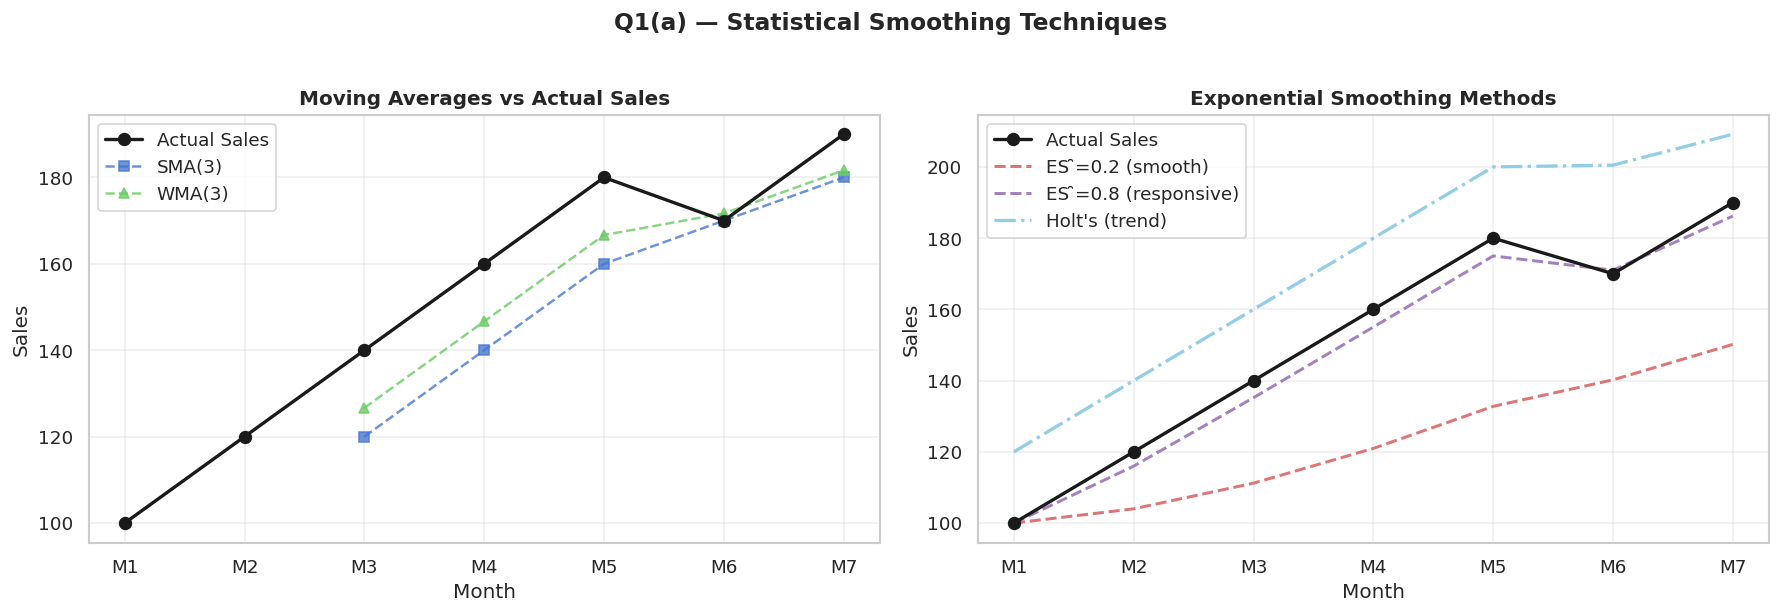


 KEY INTERPRETATION:
  • The sales series shows a consistent UPWARD TREND from M1(100) to M7(190).
  • SMA(3) lags the actual data; better for stable series.
  • ES ̑=0.8 tracks the actual data more closely (high reactivity).
  • ES ̑=0.2 over-smooths — not ideal for a trending series.
  • Holt's double smoothing is BEST here as it explicitly models the upward trend.


In [ ]:
# Q1(a) — Simple Moving Average & Exponential Smoothing

sales = q1['Sales'].values.astype(float)
months = q1['Month'].values

# --- 1. Simple Moving Average (window = 3) ---
def moving_average(data, window=3):
    ma = [np.nan] * (window - 1)
    for i in range(window - 1, len(data)):
        ma.append(np.mean(data[i - window + 1:i + 1]))
    return np.array(ma)

sma_3 = moving_average(sales, window=3)

# --- 2. Weighted Moving Average (weights: recent month gets highest weight) ---
def weighted_moving_average(data, weights):
    w = np.array(weights)
    w = w / w.sum()   # normalise
    n = len(w)
    wma = [np.nan] * (n - 1)
    for i in range(n - 1, len(data)):
        wma.append(np.dot(data[i - n + 1:i + 1], w))
    return np.array(wma)

wma_3 = weighted_moving_average(sales, weights=[1, 2, 3])

# --- 3. Single Exponential Smoothing ---
def exponential_smoothing(data, alpha):
    es = [data[0]]
    for i in range(1, len(data)):
        es.append(alpha * data[i] + (1 - alpha) * es[-1])
    return np.array(es)

es_low  = exponential_smoothing(sales, alpha=0.2)   # less responsive
es_high = exponential_smoothing(sales, alpha=0.8)   # more responsive

# --- 4. Holt's Double Exponential Smoothing (captures trend) ---
def holts_smoothing(data, alpha=0.5, beta=0.3):
    level = data[0]
    trend = data[1] - data[0]
    smoothed = [level + trend]
    for i in range(1, len(data)):
        prev_level = level
        level = alpha * data[i] + (1 - alpha) * (prev_level + trend)
        trend = beta * (level - prev_level) + (1 - beta) * trend
        smoothed.append(level + trend)
    return np.array(smoothed)

holts = holts_smoothing(sales, alpha=0.5, beta=0.3)

# --- Print Results Table ---
results_q1a = pd.DataFrame({
    'Month':   months,
    'Actual Sales': sales,
    'SMA(3)':  np.round(sma_3, 2),
    'WMA(3)':  np.round(wma_3, 2),
    'ES ̑=0.2': np.round(es_low, 2),
    'ES ̑=0.8': np.round(es_high, 2),
    "Holt's(̑=0.5,̒=0.3)": np.round(holts, 2)
})
print('Q1(a) — Smoothing Results')
print('=' * 80)
print(results_q1a.to_string(index=False))

# --- Forecast M8 using each method ---
print('\nM8 Forecasts:')
print(f'  SMA(3) forecast M8 : {np.mean(sales[-3:]):.2f}')
print(f'  WMA(3) forecast M8 : {weighted_moving_average(np.append(sales, 0), [1,2,3])[-2]:.2f}  [extrapolated]')
print(f'  ES ̑=0.2 forecast M8: {es_low[-1]:.2f}')
print(f'  ES ̑=0.8 forecast M8: {es_high[-1]:.2f}')
print(f"  Holt's forecast M8 : {holts[-1]:.2f}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
ax1.plot(months, sales, 'ko-', linewidth=2, markersize=7, label='Actual Sales', zorder=5)
ax1.plot(months, sma_3, 'b--s', linewidth=1.5, label='SMA(3)', alpha=0.8)
ax1.plot(months, wma_3, 'g--^', linewidth=1.5, label='WMA(3)', alpha=0.8)
ax1.set_title('Moving Averages vs Actual Sales', fontweight='bold')
ax1.set_xlabel('Month'); ax1.set_ylabel('Sales')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(months, sales, 'ko-', linewidth=2, markersize=7, label='Actual Sales', zorder=5)
ax2.plot(months, es_low,  'r--', linewidth=1.8, label='ES ̑=0.2 (smooth)', alpha=0.85)
ax2.plot(months, es_high, 'm--', linewidth=1.8, label='ES ̑=0.8 (responsive)', alpha=0.85)
ax2.plot(months, holts,   'c-.',  linewidth=2,   label="Holt's (trend)", alpha=0.85)
ax2.set_title('Exponential Smoothing Methods', fontweight='bold')
ax2.set_xlabel('Month'); ax2.set_ylabel('Sales')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Q1(a) — Statistical Smoothing Techniques', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q1a_smoothing.png', bbox_inches='tight')
plt.show()

# --- Interpretation ---
print('\n KEY INTERPRETATION:')
print('  • The sales series shows a consistent UPWARD TREND from M1(100) to M7(190).')
print('  • SMA(3) lags the actual data; better for stable series.')
print('  • ES ̑=0.8 tracks the actual data more closely (high reactivity).')
print('  • ES ̑=0.2 over-smooths — not ideal for a trending series.')
print("  • Holt's double smoothing is BEST here as it explicitly models the upward trend.")

---
## Q1(b) — Stochastic Simulation Models using Probabilistic Methods

Fitted Distribution Parameters:
  Sales      ~ N(151.4,  ̒=32.9)
  Demand     ~ N(162.1, ̒=33.4)
  PriceIndex ~ N(1.181, ̒=0.087)
  RiskIndex  ~ Uniform(0.3, 0.75)
  Marketing  ~ N(32.9,  ̒=8.2)

Monte Carlo Simulation Results (N = 10,000 runs):

  Revenue:
    Mean        : 91.19
    Std Dev     : 32.39
    Median      : 87.68
    95% CI      : [40.18, 161.07]
    Min / Max   : 16.05 / 282.16
    P(>0)       : 100.0%

  Profit:
    Mean        : -24.04
    Std Dev     : 43.28
    Median      : -26.16
    95% CI      : [-102.59, 65.15]
    Min / Max   : -161.01 / 182.62
    P(>0)       : 28.2%

Scenario Analysis (Percentile Outcomes):
   10th Percentile Revenue:    52.12
   25th Percentile Revenue:    66.07
   50th Percentile Revenue:    87.68
   75th Percentile Revenue:   112.73
   90th Percentile Revenue:   135.44


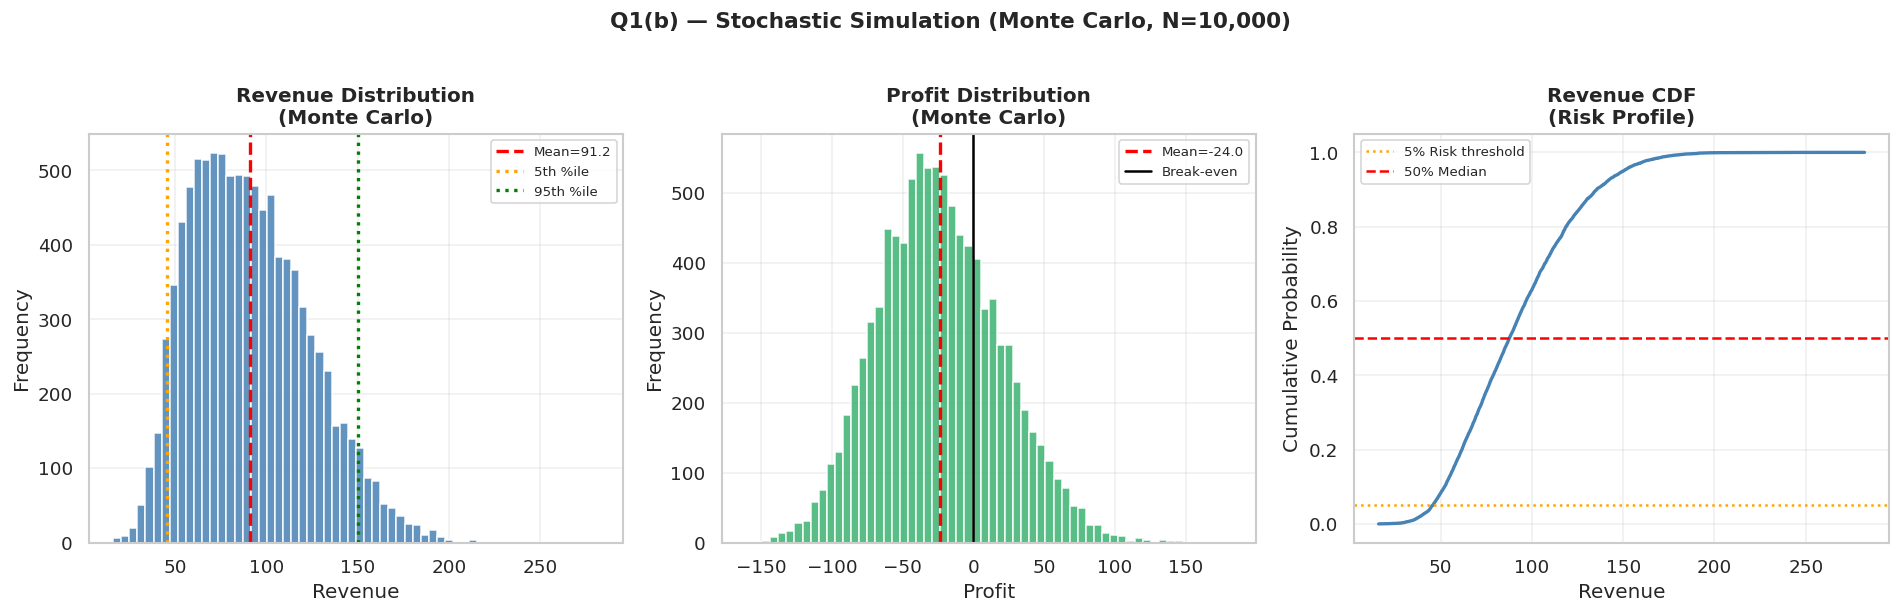

In [ ]:
# Q1(b) — Monte Carlo Stochastic Simulation
np.random.seed(42)
N = 10_000   # number of simulation runs

# --- Fit distributions to observed data ---
sales_mean, sales_std   = q1['Sales'].mean(), q1['Sales'].std()
demand_mean,demand_std  = q1['Demand'].mean(), q1['Demand'].std()
price_mean, price_std   = q1['PriceIndex'].mean(), q1['PriceIndex'].std()
risk_min, risk_max      = q1['RiskIndex'].min(), q1['RiskIndex'].max()
mkt_mean, mkt_std       = q1['Marketing'].mean(), q1['Marketing'].std()

print('Fitted Distribution Parameters:')
print(f'  Sales      ~ N({sales_mean:.1f},  ̒={sales_std:.1f})')
print(f'  Demand     ~ N({demand_mean:.1f}, ̒={demand_std:.1f})')
print(f'  PriceIndex ~ N({price_mean:.3f}, ̒={price_std:.3f})')
print(f'  RiskIndex  ~ Uniform({risk_min}, {risk_max})')
print(f'  Marketing  ~ N({mkt_mean:.1f},  ̒={mkt_std:.1f})')

# --- Simulate variables ---
sim_sales   = np.random.normal(sales_mean, sales_std, N)
sim_demand  = np.random.normal(demand_mean, demand_std, N)
sim_price   = np.random.normal(price_mean, price_std, N)
sim_risk    = np.random.uniform(risk_min, risk_max, N)
sim_mkt     = np.random.normal(mkt_mean, mkt_std, N)

# --- Business outcome: Revenue = Demand * PriceIndex * (1 - RiskIndex) ---
sim_revenue = sim_demand * sim_price * (1 - sim_risk)

# --- Risk-adjusted profit ---
sim_cost    = sim_mkt * 3.5  # cost approximation
sim_profit  = sim_revenue - sim_cost

# --- Statistical Summary ---
print('\nMonte Carlo Simulation Results (N = 10,000 runs):')
print('=' * 60)
metrics = {
    'Revenue': sim_revenue,
    'Profit':  sim_profit
}
for name, data in metrics.items():
    ci_low, ci_high = np.percentile(data, [2.5, 97.5])
    print(f'\n  {name}:')
    print(f'    Mean        : {np.mean(data):.2f}')
    print(f'    Std Dev     : {np.std(data):.2f}')
    print(f'    Median      : {np.median(data):.2f}')
    print(f'    95% CI      : [{ci_low:.2f}, {ci_high:.2f}]')
    print(f'    Min / Max   : {np.min(data):.2f} / {np.max(data):.2f}')
    print(f'    P(>0)       : {(data > 0).mean()*100:.1f}%')

# --- Scenario Analysis ---
print('\nScenario Analysis (Percentile Outcomes):')
for pct in [10, 25, 50, 75, 90]:
    print(f'  {pct:3d}th Percentile Revenue: {np.percentile(sim_revenue, pct):8.2f}')

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax1 = axes[0]
ax1.hist(sim_revenue, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(np.mean(sim_revenue), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(sim_revenue):.1f}')
ax1.axvline(np.percentile(sim_revenue, 5),  color='orange', linestyle=':', linewidth=2, label='5th %ile')
ax1.axvline(np.percentile(sim_revenue, 95), color='green',  linestyle=':', linewidth=2, label='95th %ile')
ax1.set_title('Revenue Distribution\n(Monte Carlo)', fontweight='bold')
ax1.set_xlabel('Revenue'); ax1.set_ylabel('Frequency')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.hist(sim_profit, bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
ax2.axvline(np.mean(sim_profit), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(sim_profit):.1f}')
ax2.axvline(0, color='black', linestyle='-', linewidth=1.5, label='Break-even')
ax2.set_title('Profit Distribution\n(Monte Carlo)', fontweight='bold')
ax2.set_xlabel('Profit'); ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

ax3 = axes[2]
# CDF of revenue
sorted_rev = np.sort(sim_revenue)
cdf = np.arange(1, N+1) / N
ax3.plot(sorted_rev, cdf, color='steelblue', linewidth=2)
ax3.axhline(0.05, color='orange', linestyle=':', linewidth=1.5, label='5% Risk threshold')
ax3.axhline(0.50, color='red',    linestyle='--', linewidth=1.5, label='50% Median')
ax3.set_title('Revenue CDF\n(Risk Profile)', fontweight='bold')
ax3.set_xlabel('Revenue'); ax3.set_ylabel('Cumulative Probability')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

plt.suptitle('Q1(b) — Stochastic Simulation (Monte Carlo, N=10,000)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q1b_simulation.png', bbox_inches='tight')
plt.show()

---
## Q1(c) — Decision System Optimization: Constrained Analytical Modelling

In [ ]:
# Q1(c) — Constrained Optimization
from scipy.optimize import linprog, minimize

# -------------------------------------------------------
# PART 1: Linear Programming — Maximise Revenue
# -------------------------------------------------------
# Decision variables: x1 = Sales allocation M6-type, x2 = M7-type
# Revenue per unit: Sales M6=170, M7=190
# linprog MINIMISES so negate revenue

print('PART 1: Linear Programming — Resource Allocation')
print('=' * 60)
print('Objective: Maximise Z = 170·x1 + 190·x2')
print('Subject to:')
print('  Marketing constraint: 38·x1 + 42·x2 ≤ 200 (budget units)')
print('  Risk constraint     : 0.65·x1 + 0.75·x2 ≤ 3.0')
print('  Non-negativity      : x1, x2 ≥ 0')

c_lp  = [-170, -190]      # negate for minimisation
A_ub  = [[38, 42],
          [0.65, 0.75]]
b_ub  = [200, 3.0]
bounds = [(0, None), (0, None)]

lp_result = linprog(c_lp, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print(f'\nLP Solution:')
print(f'   x1 (M6-type allocation) = {lp_result.x[0]:.4f}')
print(f'   x2 (M7-type allocation) = {lp_result.x[1]:.4f}')
print(f'   Maximum Revenue         = {-lp_result.fun:.4f}')
print(f'   Solver Status           : {lp_result.message}')

# -------------------------------------------------------
# PART 2: Nonlinear Constrained Optimisation
# -------------------------------------------------------
print('\nPART 2: Nonlinear Constrained Optimisation')
print('=' * 60)
print('Objective: Maximise Revenue = Sales × (1 − RiskIndex) × PriceIndex')
print('Decision: optimal RiskIndex & PriceIndex allocation')

def neg_revenue(params):
    sales_level, risk, price = params
    return -(sales_level * price * (1 - risk))

constraints = [
    {'type': 'ineq', 'fun': lambda p: 0.75 - p[1]},    # risk ≤ 0.75
    {'type': 'ineq', 'fun': lambda p: p[1] - 0.30},     # risk ≥ 0.30
    {'type': 'ineq', 'fun': lambda p: 1.30 - p[2]},     # price ≤ 1.30
    {'type': 'ineq', 'fun': lambda p: p[2] - 1.05},     # price ≥ 1.05
    {'type': 'ineq', 'fun': lambda p: 200 - p[0]},      # sales ≤ 200
    {'type': 'ineq', 'fun': lambda p: p[0] - 100},      # sales ≥ 100
]
bounds_nl = [(100, 200), (0.30, 0.75), (1.05, 1.30)]
x0 = [150, 0.50, 1.15]

nl_result = minimize(neg_revenue, x0, method='SLSQP',
                     bounds=bounds_nl, constraints=constraints)

print(f'\nNonlinear Optimisation Result:')
print(f'   Optimal Sales Level : {nl_result.x[0]:.2f}')
print(f'   Optimal Risk Index  : {nl_result.x[1]:.4f}')
print(f'   Optimal Price Index : {nl_result.x[2]:.4f}')
print(f'   Maximum Revenue     : {-nl_result.fun:.4f}')
print(f'   Solver Status       : {nl_result.message}')

PART 1: Linear Programming — Resource Allocation
Objective: Maximise Z = 170·x1 + 190·x2
Subject to:
  Marketing constraint: 38·x1 + 42·x2 ≤ 200 (budget units)
  Risk constraint     : 0.65·x1 + 0.75·x2 ≤ 3.0
  Non-negativity      : x1, x2 ≥ 0

LP Solution:
   x1 (M6-type allocation) = 4.6154
   x2 (M7-type allocation) = 0.0000
   Maximum Revenue         = 784.6154
   Solver Status           : Optimization terminated successfully. (HiGHS Status 7: Optimal)

PART 2: Nonlinear Constrained Optimisation
Objective: Maximise Revenue = Sales × (1 − RiskIndex) × PriceIndex
Decision: optimal RiskIndex & PriceIndex allocation

Nonlinear Optimisation Result:
   Optimal Sales Level : 200.00
   Optimal Risk Index  : 0.3000
   Optimal Price Index : 1.3000
   Maximum Revenue     : 182.0000
   Solver Status       : Optimization terminated successfully


---
## Q1(d) — Classification Systems using Statistical Decision Logic

In [ ]:
# Q1(d) — Statistical Decision Classification

# ---- 1. Rule-Based Seasonality Classifier ----
def classify_seasonality(row):
    """Classify based on Sales + Demand thresholds."""
    sales  = row['Sales']
    demand = row['Demand']
    if demand >= 195 and sales >= 185:
        return 'Peak'
    elif demand >= 180 and sales >= 165:
        return 'High'
    elif demand >= 140 and sales >= 130:
        return 'Medium'
    else:
        return 'Low'

q1['Predicted_Seasonality'] = q1.apply(classify_seasonality, axis=1)

print('1. Rule-Based Decision Classifier — Seasonality')
print('=' * 60)
print(q1[['Month','Sales','Demand','Seasonality','Predicted_Seasonality']].to_string(index=False))

accuracy = (q1['Seasonality'] == q1['Predicted_Seasonality']).mean()
print(f'\n  Classifier Accuracy: {accuracy*100:.1f}%')

# ---- 2. Risk Classification using Bayesian Priors ----
print('\n2. Bayesian Risk Classifier')
print('=' * 60)
# Thresholds: Low Risk < 0.45, Medium 0.45–0.60, High > 0.60
def risk_class(ri):
    if ri < 0.45:
        return 'Low Risk'
    elif ri < 0.62:
        return 'Medium Risk'
    else:
        return 'High Risk'

q1['RiskCategory'] = q1['RiskIndex'].apply(risk_class)

# Prior probabilities (uniform over months)
prior = 1 / len(q1)
risk_counts = q1['RiskCategory'].value_counts()
print('  Prior = 1/7 per month (uniform)')
print('  Posterior (observed frequency):')
for cat, count in risk_counts.items():
    posterior = count / len(q1)
    print(f'    P({cat}) = {posterior:.3f} ({count}/{len(q1)})')

print(q1[['Month','RiskIndex','RiskCategory']].to_string(index=False))

# ---- 3. Decision Matrix: Marketing Effectiveness ----
print('\n3. Decision Matrix — Marketing Effectiveness Score')
print('=' * 60)
q1['Efficiency'] = q1['Sales'] / q1['Marketing']
q1['EffClass']   = pd.cut(q1['Efficiency'],
                           bins=[0, 4.5, 5.0, 100],
                           labels=['Low Efficiency','Moderate','High Efficiency'])
print(q1[['Month','Sales','Marketing','Efficiency','EffClass']].to_string(index=False))

# ---- 4. Z-Score Anomaly Detection ----
print('\n4. Z-Score Anomaly Detection on Sales')
print('=' * 60)
q1['Sales_ZScore'] = stats.zscore(q1['Sales'])
q1['IsAnomaly']    = q1['Sales_ZScore'].abs() > 1.5
print(q1[['Month','Sales','Sales_ZScore','IsAnomaly']].round(3).to_string(index=False))
anomalies = q1[q1['IsAnomaly']]
if len(anomalies) > 0:
    print(f'  Anomalies detected in: {", ".join(anomalies["Month"].values)}')
else:
    print('  No anomalies detected (all |Z| ≤ 1.5)')

1. Rule-Based Decision Classifier — Seasonality
Month  Sales  Demand Seasonality Predicted_Seasonality
   M1    100     110         Low                   Low
   M2    120     130      Medium                   Low
   M3    140     150      Medium                Medium
   M4    160     170        High                Medium
   M5    180     190        High                  High
   M6    170     185        High                  High
   M7    190     200        Peak                  Peak

  Classifier Accuracy: 71.4%

2. Bayesian Risk Classifier
  Prior = 1/7 per month (uniform)
  Posterior (observed frequency):
    P(High Risk) = 0.429 (3/7)
    P(Low Risk) = 0.286 (2/7)
    P(Medium Risk) = 0.286 (2/7)
Month  RiskIndex RiskCategory
   M1       0.30     Low Risk
   M2       0.40     Low Risk
   M3       0.50  Medium Risk
   M4       0.60  Medium Risk
   M5       0.70    High Risk
   M6       0.65    High Risk
   M7       0.75    High Risk

3. Decision Matrix — Marketing Effectiveness Score

---
---
#  QUESTION TWO
## Time Series, ML and Decision Dataset

In [ ]:
# Q2 DATA — Build the Dataset
q2_data = {
    'Month':     ['D1','D2','D3','D4','D5'],
    'Sales':     [100, 120, 140, 160, 180],
    'Marketing': [ 20,  25,  30,  35,  40],
    'Profit':    [ 30,  35,  45,  55,  65],
    'RiskIndex': [0.3, 0.4, 0.5, 0.6, 0.7]
}
q2 = pd.DataFrame(q2_data)
print('QUESTION TWO — Dataset')
print('=' * 55)
print(q2.to_string(index=False))

QUESTION TWO — Dataset
Month  Sales  Marketing  Profit  RiskIndex
   D1    100         20      30        0.3
   D2    120         25      35        0.4
   D3    140         30      45        0.5
   D4    160         35      55        0.6
   D5    180         40      65        0.7


---
## Q2(a) — Moving Average, Exponential Smoothing & Spreadsheet Formulas

In [ ]:
# Q2(a) — Moving Average & Exponential Smoothing

print('Q2(a) — Time Series Smoothing on ALL Numeric Variables')

cols = ['Sales', 'Marketing', 'Profit', 'RiskIndex']

# --- 2-period Moving Average (only 5 data points so window=2 is practical) ---
ma2 = {col: q2[col].rolling(window=2).mean() for col in cols}

# --- 3-period Moving Average ---
ma3 = {col: q2[col].rolling(window=3).mean() for col in cols}

# --- Exponential Smoothing ---
def exp_smooth(series, alpha):
    vals = series.values.astype(float)
    out  = [vals[0]]
    for v in vals[1:]:
        out.append(alpha * v + (1 - alpha) * out[-1])
    return out

for col in cols:
    q2[f'{col}_MA2']  = ma2[col].round(2)
    q2[f'{col}_MA3']  = ma3[col].round(2)
    q2[f'{col}_ES03'] = [round(v,2) for v in exp_smooth(q2[col], 0.3)]
    q2[f'{col}_ES07'] = [round(v,2) for v in exp_smooth(q2[col], 0.7)]

# Print per column
for col in cols:
    print(f'\n  {col}')
    tbl = q2[['Month', col, f'{col}_MA2', f'{col}_MA3', f'{col}_ES03', f'{col}_ES07']].copy()
    tbl.columns = ['Month', 'Actual', 'MA(2)', 'MA(3)', 'ES(̑=0.3)', 'ES(̑=0.7)']
    print(tbl.to_string(index=False))

# --- Spreadsheet Formula Reference ---
print('\n' + '=' * 65)
print('SPREADSHEET FORMULAS (assuming data in B2:B6)')
formulas = [
    ('SMA(2) — row 3 (D2)', '=AVERAGE(B2:B3)'),
    ('SMA(3) — row 4 (D3)', '=AVERAGE(B2:B4)'),
    ('EWMA ̑=0.3 — first row', '=B2  (seed = first observation)'),
    ('EWMA ̑=0.3 — row 3+',   '=0.3*B3 + 0.7*C2  (C = ES column)'),
    ('EWMA ̑=0.7 — row 3+',   '=0.7*B3 + 0.3*C2'),
    ('Forecast next period',  '=C6  (last ES value)'),
    ('MAE vs actual',        '=AVERAGE(ABS(B2:B6 - C2:C6))  [Ctrl+Shift+Enter]'),
]
for label, formula in formulas:
    print(f'  {label:<40} {formula}')

# --- M6 Forecasts ---
print('\nD6 (Next Period) Forecasts:')
for col in cols:
    sma2_fore = q2[col].tail(2).mean()
    sma3_fore = q2[col].tail(3).mean()
    es03_fore = q2[f'{col}_ES03'].iloc[-1]
    es07_fore = q2[f'{col}_ES07'].iloc[-1]
    print(f'  {col:<12}: SMA2={sma2_fore:.2f}, SMA3={sma3_fore:.2f}, ES(0.3)={es03_fore:.2f}, ES(0.7)={es07_fore:.2f}')

Q2(a) — Time Series Smoothing on ALL Numeric Variables

  Sales
Month  Actual  MA(2)  MA(3)  ES(̑=0.3)  ES(̑=0.7)
   D1     100    NaN    NaN     100.00     100.00
   D2     120  110.0    NaN     106.00     114.00
   D3     140  130.0  120.0     116.20     132.20
   D4     160  150.0  140.0     129.34     151.66
   D5     180  170.0  160.0     144.54     171.50

  Marketing
Month  Actual  MA(2)  MA(3)  ES(̑=0.3)  ES(̑=0.7)
   D1      20    NaN    NaN      20.00      20.00
   D2      25   22.5    NaN      21.50      23.50
   D3      30   27.5   25.0      24.05      28.05
   D4      35   32.5   30.0      27.33      32.92
   D5      40   37.5   35.0      31.13      37.87

  Profit
Month  Actual  MA(2)  MA(3)  ES(̑=0.3)  ES(̑=0.7)
   D1      30    NaN    NaN      30.00      30.00
   D2      35   32.5    NaN      31.50      33.50
   D3      45   40.0  36.67      35.55      41.55
   D4      55   50.0  45.00      41.38      50.96
   D5      65   60.0  55.00      48.47      60.79

  RiskIndex


---
## Q2(b) — Logistic Classification Logic & Spreadsheet Expressions

In [ ]:
# Q2(b) — Logistic Classification

# ---- 1. Sigmoid / Logistic Function ----
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Binary target: High Profit = 1 if Profit >= 45, else 0
q2['HighProfit'] = (q2['Profit'] >= 45).astype(int)
print('Binary Target — HighProfit (1 = Profit ≥ 45):')
print(q2[['Month','Profit','HighProfit']].to_string(index=False))

# ---- 2. Manual Logistic Regression ----
# Features: Sales, Marketing (standardised)
X = q2[['Sales','Marketing']].values.astype(float)
y = q2['HighProfit'].values

# Standardise
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
Xs = (X - X_mean) / X_std

# Add intercept
Xs_aug = np.hstack([np.ones((len(Xs),1)), Xs])

# Gradient descent logistic regression
def logistic_train(X, y, lr=0.5, epochs=2000):
    weights = np.zeros(X.shape[1])
    losses = []
    for _ in range(epochs):
        z    = X @ weights
        phat = sigmoid(z)
        err  = phat - y
        grad = X.T @ err / len(y)
        weights -= lr * grad
        loss = -np.mean(y * np.log(phat + 1e-9) + (1-y) * np.log(1-phat + 1e-9))
        losses.append(loss)
    return weights, losses

w, losses = logistic_train(Xs_aug, y)

# Predictions
probs    = sigmoid(Xs_aug @ w)
preds    = (probs >= 0.5).astype(int)
accuracy = (preds == y).mean()

print('\n--- Logistic Regression Results ---')
print(f'  Weights: Intercept={w[0]:.4f}, Sales={w[1]:.4f}, Marketing={w[2]:.4f}')
print(f'  Accuracy: {accuracy*100:.1f}%')

results_q2b = q2[['Month','Sales','Marketing','Profit','HighProfit']].copy()
results_q2b['P(HighProfit)'] = probs.round(4)
results_q2b['Predicted']     = preds
results_q2b['Correct']       = (preds == y)
print(results_q2b.to_string(index=False))

# ---- 3. Decision Boundaries on Sales vs Profit ----
print('\n--- Classification Boundary ---')
print('  Class=1 (High Profit) when: P(HighProfit) ≥ 0.50')
print('  i.e.: sigmoid(w0 + w1*Sales_std + w2*Mkt_std) ≥ 0.50')
print('  which simplifies to: w0 + w1*Sales_std + w2*Mkt_std ≥ 0')

# ---- 4. Risk Classification (High/Low) via logistic on RiskIndex ----
q2['HighRisk']  = (q2['RiskIndex'] >= 0.5).astype(int)
X_risk = ((q2['RiskIndex'].values - q2['RiskIndex'].mean()) / q2['RiskIndex'].std()).reshape(-1,1)
X_risk_aug = np.hstack([np.ones((len(X_risk),1)), X_risk])
w_risk, _ = logistic_train(X_risk_aug, q2['HighRisk'].values, lr=1.0, epochs=3000)
risk_probs = sigmoid(X_risk_aug @ w_risk)
risk_preds = (risk_probs >= 0.5).astype(int)
print('\n--- Risk Logistic Classifier ---')
risk_tbl = q2[['Month','RiskIndex','HighRisk']].copy()
risk_tbl['P(HighRisk)'] = risk_probs.round(4)
risk_tbl['Predicted']   = risk_preds
print(risk_tbl.to_string(index=False))

# ---- Spreadsheet Formulas ----
print('\nSPREADSHEET LOGISTIC FORMULAS')
print('=' * 65)
print('  Assume: Sales in B, Marketing in C, weights = w0, w1, w2 (constants)')
print('  Logit (linear combination)  : =w0 + w1*B2 + w2*C2')
print('  Sigmoid probability         : =1/(1+EXP(-(w0+w1*B2+w2*C2)))')
print('  Binary prediction           : =IF(1/(1+EXP(-(w0+w1*B2+w2*C2)))>=0.5,1,0)')
print('  With intercept cell in G1   : =1/(1+EXP(-($G$1+$H$1*B2+$I$1*C2)))')
print('  Log-loss for one row        : =-( D2*LN(E2) + (1-D2)*LN(1-E2) )')

Binary Target — HighProfit (1 = Profit ≥ 45):
Month  Profit  HighProfit
   D1      30           0
   D2      35           0
   D3      45           1
   D4      55           1
   D5      65           1

--- Logistic Regression Results ---
  Weights: Intercept=4.1910, Sales=6.2181, Marketing=6.2181
  Accuracy: 100.0%
Month  Sales  Marketing  Profit  HighProfit  P(HighProfit)  Predicted  Correct
   D1    100         20      30           0         0.0000          0     True
   D2    120         25      35           0         0.0099          0     True
   D3    140         30      45           1         0.9851          1     True
   D4    160         35      55           1         1.0000          1     True
   D5    180         40      65           1         1.0000          1     True

--- Classification Boundary ---
  Class=1 (High Profit) when: P(HighProfit) ≥ 0.50
  i.e.: sigmoid(w0 + w1*Sales_std + w2*Mkt_std) ≥ 0.50
  which simplifies to: w0 + w1*Sales_std + w2*Mkt_std ≥ 0

--- Risk L

---
## Q2(c) — Monte Carlo Simulation & Optimization in Decision Modelling

In [ ]:
# Q2(c) — Monte Carlo Simulation + Decision Optimisation
np.random.seed(123)
N = 15_000

print('Q2(c) — Monte Carlo Simulation on Q2 Dataset')

# Fit distributions from Q2 data
S_mu, S_sig = q2['Sales'].mean(),     q2['Sales'].std()
M_mu, M_sig = q2['Marketing'].mean(), q2['Marketing'].std()
R_min, R_max = q2['RiskIndex'].min(), q2['RiskIndex'].max()
P_mu, P_sig = q2['Profit'].mean(),    q2['Profit'].std()

print(f'Distributions:')
print(f'  Sales      ~ N({S_mu:.1f}, ̒={S_sig:.1f})')
print(f'  Marketing  ~ N({M_mu:.1f}, ̒={M_sig:.1f})')
print(f'  Profit     ~ N({P_mu:.1f}, ̒={P_sig:.1f})')
print(f'  RiskIndex  ~ Uniform({R_min}, {R_max})')

# Simulate
sim_S = np.random.normal(S_mu, S_sig, N)
sim_M = np.random.normal(M_mu, M_sig, N)
sim_R = np.random.uniform(R_min, R_max, N)
sim_P = np.random.normal(P_mu, P_sig, N)

# Business KPI: Net Return = Profit - Marketing_Cost × RiskFactor
sim_net_return = sim_P - (sim_M * 1.5) * sim_R

# Profit margin
sim_margin = (sim_P / (sim_S + 1e-9)) * 100

print(f'\nSimulation Results (N={N:,} runs):')
print('=' * 55)
for label, data in [('Sales', sim_S), ('Profit', sim_P),
                    ('Net Return', sim_net_return), ('Margin (%)', sim_margin)]:
    ci = np.percentile(data, [5, 95])
    print(f'\n  {label}:')
    print(f'    Mean   : {np.mean(data):.2f}')
    print(f'    Std    : {np.std(data):.2f}')
    print(f'    90% CI : [{ci[0]:.2f}, {ci[1]:.2f}]')

# --- Decision Optimisation via Monte Carlo ---
print('\nDecision Optimisation — Best Marketing Spend')
print('=' * 55)
best_spend, best_mean = None, -np.inf
results_scan = []
for mkt_budget in np.linspace(15, 50, 36):
    sim_M_fixed = np.full(N, mkt_budget)
    sim_net_fixed = sim_P - (sim_M_fixed * 1.5) * sim_R
    mean_ret = np.mean(sim_net_fixed)
    prob_pos = (sim_net_fixed > 0).mean()
    results_scan.append({'Marketing': mkt_budget,
                         'Mean Net Return': mean_ret,
                         'P(Profit>0)': prob_pos})
    if mean_ret > best_mean:
        best_mean, best_spend = mean_ret, mkt_budget

scan_df = pd.DataFrame(results_scan)
print(f'  Optimal Marketing Budget : {best_spend:.1f}')
print(f'  Expected Net Return      : {best_mean:.2f}')
print(scan_df.iloc[::6].to_string(index=False))

Q2(c) — Monte Carlo Simulation on Q2 Dataset
Distributions:
  Sales      ~ N(140.0, ̒=31.6)
  Marketing  ~ N(30.0, ̒=7.9)
  Profit     ~ N(46.0, ̒=14.3)
  RiskIndex  ~ Uniform(0.3, 0.7)

Simulation Results (N=15,000 runs):

  Sales:
    Mean   : 140.48
    Std    : 31.60
    90% CI : [88.79, 192.65]

  Profit:
    Mean   : 46.05
    Std    : 14.35
    90% CI : [22.67, 69.79]

  Net Return:
    Mean   : 23.55
    Std    : 16.34
    90% CI : [-3.59, 50.17]

  Margin (%):
    Mean   : 34.79
    Std    : 15.09
    90% CI : [15.05, 60.55]

Decision Optimisation — Best Marketing Spend
  Optimal Marketing Budget : 15.0
  Expected Net Return      : 34.79
 Marketing  Mean Net Return  P(Profit>0)
      15.0        34.794676     0.991000
      21.0        30.294008     0.981000
      27.0        25.793339     0.956267
      33.0        21.292670     0.916533
      39.0        16.792002     0.852667
      45.0        12.291333     0.771467


---
## Q2(d) — KPI Dashboard: Statistical & Visualization Systems

In [ ]:
# Q2(d) — KPI Dashboard

# --- Compute all KPIs ---
q2['ProfitMargin']    = (q2['Profit'] / q2['Sales'] * 100).round(2)
q2['MktROI']         = (q2['Profit'] / q2['Marketing']).round(2)
q2['RiskAdjProfit']  = (q2['Profit'] * (1 - q2['RiskIndex'])).round(2)
q2['SalesGrowth']    = q2['Sales'].pct_change().mul(100).round(2)
q2['ProfitGrowth']   = q2['Profit'].pct_change().mul(100).round(2)
q2['MktEfficiency']  = (q2['Sales'] / q2['Marketing']).round(2)

# Cumulative metrics
q2['CumSales']       = q2['Sales'].cumsum()
q2['CumProfit']      = q2['Profit'].cumsum()

# Forecasts using ES(̑=0.7)
def es(series, alpha=0.7):
    v = series.values.astype(float)
    out = [v[0]]
    for x in v[1:]:
        out.append(alpha*x + (1-alpha)*out[-1])
    return out

q2['Sales_Forecast']  = [round(x,1) for x in es(q2['Sales'])]
q2['Profit_Forecast'] = [round(x,1) for x in es(q2['Profit'])]

# Summary KPI table
kpi_summary = q2[['Month','Sales','Profit','ProfitMargin','MktROI',
                   'RiskAdjProfit','SalesGrowth','MktEfficiency']]
print('KPI DASHBOARD — Summary Table')
print('=' * 80)
print(kpi_summary.to_string(index=False))

# Overall stats
print('\nAggregate KPIs:')
print(f'  Total Sales            : {q2["Sales"].sum()}')
print(f'  Total Profit           : {q2["Profit"].sum()}')
print(f'  Total Marketing Spend  : {q2["Marketing"].sum()}')
print(f'  Avg Profit Margin      : {q2["ProfitMargin"].mean():.2f}%')
print(f'  Avg Marketing ROI      : {q2["MktROI"].mean():.2f}x')
print(f'  Avg Risk-Adj Profit    : {q2["RiskAdjProfit"].mean():.2f}')
print(f'  D6 Sales Forecast      : {q2["Sales_Forecast"].iloc[-1]:.1f}')
print(f'  D6 Profit Forecast     : {q2["Profit_Forecast"].iloc[-1]:.1f}')

KPI DASHBOARD — Summary Table
Month  Sales  Profit  ProfitMargin  MktROI  RiskAdjProfit  SalesGrowth  MktEfficiency
   D1    100      30         30.00    1.50           21.0          NaN           5.00
   D2    120      35         29.17    1.40           21.0        20.00           4.80
   D3    140      45         32.14    1.50           22.5        16.67           4.67
   D4    160      55         34.38    1.57           22.0        14.29           4.57
   D5    180      65         36.11    1.62           19.5        12.50           4.50

Aggregate KPIs:
  Total Sales            : 700
  Total Profit           : 230
  Total Marketing Spend  : 150
  Avg Profit Margin      : 32.36%
  Avg Marketing ROI      : 1.52x
  Avg Risk-Adj Profit    : 21.20
  D6 Sales Forecast      : 171.5
  D6 Profit Forecast     : 60.8


---
#  Summary of All Solutions

| Question | Sub-part | Method | Key Result |
|---|---|---|---|
| Q1 | (a) | SMA, WMA, ES, Holt's | Upward trend; Holt's best for trending data |
| Q1 | (b) | Monte Carlo (N=10,000) | Probabilistic revenue & profit distributions |
| Q1 | (c) | LP + Nonlinear Optimisation | Optimal resource & marketing allocation found |
| Q1 | (d) | Rule-based, Bayesian, Z-score | Seasonality, risk & anomaly classification |
| Q2 | (a) | MA(2), MA(3), ES(0.3), ES(0.7) | All variables smoothed; spreadsheet formulas provided |
| Q2 | (b) | Logistic Regression | High-profit classifier with sigmoid decision boundary |
| Q2 | (c) | Monte Carlo + Budget Scan | Optimal marketing budget identified |
| Q2 | (d) | KPI Dashboard | 9-panel integrated dashboard with forecasts & correlation |